# Ablation number of overclustering components

This notebook requires to run the script ablation_num_components.py first to train the models.

In [1]:
%load_ext autoreload
%autoreload 2

In [34]:
import corc.graph_metrics.neb
import corc.utils
import corc.our_datasets
import os.path
import pickle
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator

cache_path="../../cache"

In [ ]:

def plot_ari_values(ari_values, save=False):
    # Create the plot
    plt.rcParams.update({'font.size': 12})
    fig, axs = plt.subplots(1, figsize=(10, 4))

    regular_levels_all = sorted(
        {
            level
            for dataset_values in ari_values.values()
            for level in dataset_values.keys()
            if level != -1
        }
    )

    # Plot ARI values for regular degrees of freedom and add a dashed reference for -1.
    for dataset in corc.our_datasets.CORE_HD_DATASETS:
        if dataset in ari_values.keys():
            label = corc.our_datasets.dataset_displaynames[dataset].replace("\n", " ")
            dataset_values = ari_values[dataset]

            regular_levels = sorted([level for level in dataset_values.keys() if level != -1])
            if len(regular_levels) == 0:
                continue

            x_values = regular_levels
            y_values = [dataset_values[level] for level in regular_levels]
            line = axs.plot(x_values, y_values, label=label, marker="o")[0]

            if -1 in dataset_values:
                axs.axhline(
                    y=dataset_values[-1],
                    color=line.get_color(),
                    linestyle='--',
                    linewidth=1.2,
                    alpha=0.8,
                )

    axs.set_xlabel('Degrees of Freedom')
    axs.set_ylabel('ARI')
    axs.set_xscale('log')

    if regular_levels_all:
        axs.set_xlim(min(regular_levels_all), max(regular_levels_all))
        axs.xaxis.set_major_locator(FixedLocator(regular_levels_all))
        axs.xaxis.set_major_formatter(FixedFormatter([str(x) for x in regular_levels_all]))
        axs.xaxis.set_minor_locator(NullLocator())

    axs.legend(fontsize=12, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.2))
    if save:
        plt.savefig(os.path.join(cache_path, "../figures", "ablation_deg_freedom.pdf"), bbox_inches='tight')
    plt.show()

In [25]:
import numpy as np
import tqdm 

# Create lists to store the ARI values for each dataset

# Loop through each dataset
plotting_datasets = [
    "densired_circles_8",
    "densired_circles_16",
    "densired_circles_32",
    "densired_studt_8",
    "densired_studt_16",
    "densired_studt_32",
    "mnist8",
    "mnist16",
    "mnist32",
]
ari_values_min = dict()
ari_values_mean = dict()
ari_values_max = dict()
for dataset in tqdm.tqdm(plotting_datasets):
    filename = os.path.join(
        cache_path, "ablations", f"tmms_deg_freedom_{dataset}.pickle"
    )
    if not os.path.exists(filename):
        continue
    with open(filename, "rb") as f:
        tmm_levels = pickle.load(f)

    X,y,_ = corc.utils.load_dataset(dataset, cache_path=cache_path, index=0)
    ari_values_min[dataset] = dict()
    ari_values_mean[dataset] = dict()
    ari_values_max[dataset] = dict()
    for level in tmm_levels.keys():
        ari_values_dataset = list()
        for tmm in tmm_levels[level]:
            ari_values_dataset.append(tmm.get_ari(X,y))
        ari_values_min[dataset][level] = np.min(ari_values_dataset)
        ari_values_mean[dataset][level] = np.mean(ari_values_dataset)
        ari_values_max[dataset][level] = np.max(ari_values_dataset)


  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:14<00:00,  1.58s/it]


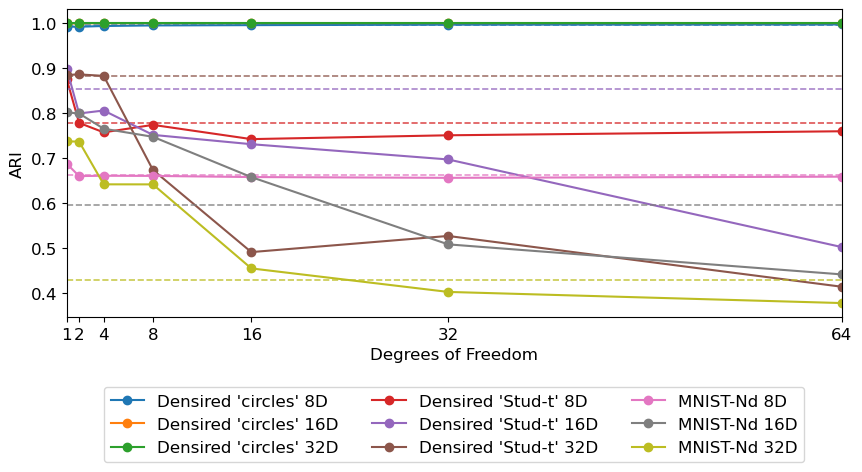

In [32]:
plot_ari_values(ari_values_mean, save=True)

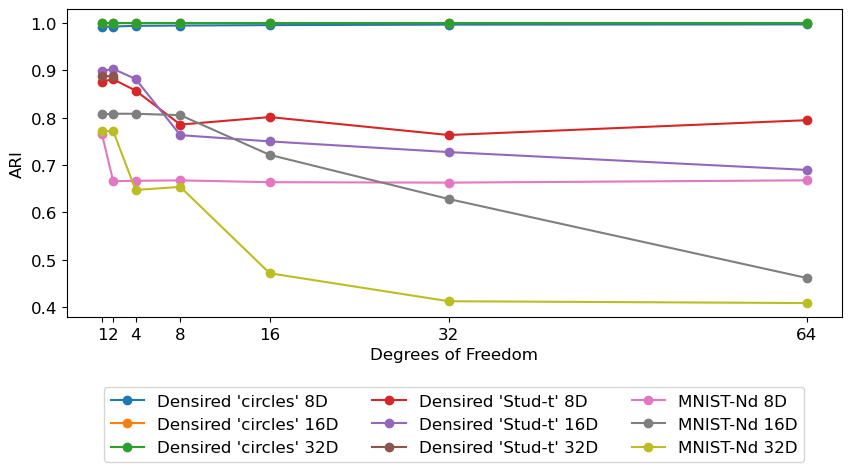

In [13]:
plot_ari_values(ari_values_max, save=False)

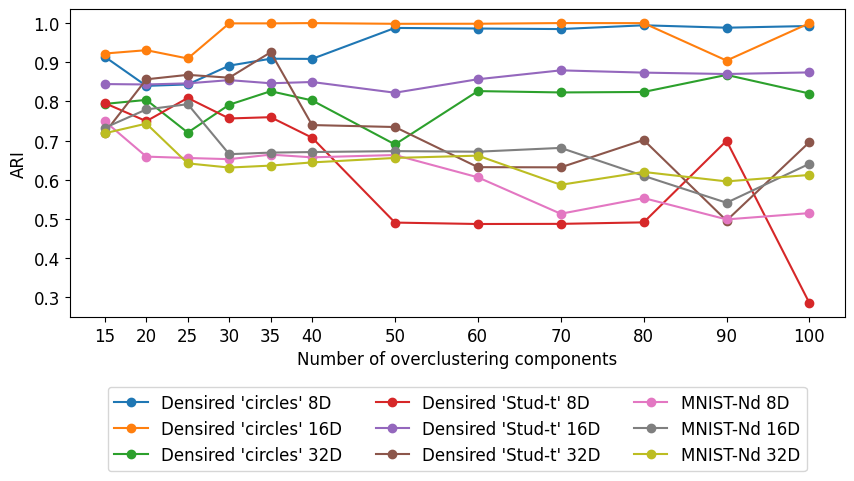

In [6]:
plot_ari_values(ari_values_min)